In [ ]:

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")


In [ ]:
# import warnings
# warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")

movies = pd.read_csv("movie.csv")    # movieId, title, genres
print(movies.shape)
movies

(27278, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund für's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [ ]:
ratings = pd.read_csv("rating.csv")    # userId, movieId, rating, timestamp
print(ratings.shape)
ratings

(20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40
...,...,...,...,...
20000258,138493,68954,4.5,2009-11-13 15:42:00
20000259,138493,69526,4.5,2009-12-03 18:31:48
20000260,138493,69644,3.0,2009-12-07 18:10:57
20000261,138493,70286,5.0,2009-11-13 15:42:24


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


In [ ]:
import numpy as np
ratings["rating"].describe()

,rating
count,2.000026e+07
mean,3.525529e+00
std,1.051989e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


In [ ]:
print((ratings["rating"] >= 4.5).sum())

4433484


In [ ]:
# Step 2: Filter liked movies (rating >= 4.0)
ratings_filtered = ratings[ratings["rating"] >= 4.0]
ratings_filtered

,userId,movieId,rating,timestamp
6,1,151,4.0,2004-09-10 03:08:54
7,1,223,4.0,2005-04-02 23:46:13
8,1,253,4.0,2005-04-02 23:35:40
9,1,260,4.0,2005-04-02 23:33:46
10,1,293,4.0,2005-04-02 23:31:43
...,...,...,...,...
20000256,138493,66762,4.5,2009-10-17 18:50:08
20000257,138493,68319,4.5,2009-12-07 18:15:20
20000258,138493,68954,4.5,2009-11-13 15:42:00
20000259,138493,69526,4.5,2009-12-03 18:31:48


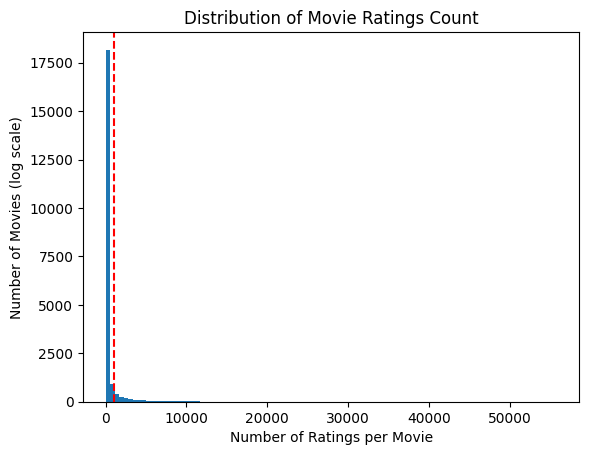

Number of movies with >= 1000 ratings: 1785
>=100: 5712
>=3000: 801
>=5000: 461
>=10000: 200


In [ ]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")

movie_counts = ratings_filtered["movieId"].value_counts()
plt.hist(movie_counts, bins=100, log=False)
plt.axvline(x=1000, color='r', linestyle='--')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies (log scale)')
plt.title('Distribution of Movie Ratings Count')
plt.show()

print(f"Number of movies with >= 1000 ratings: {(movie_counts >= 1000).sum()}")
movie_counts = ratings_filtered["movieId"].value_counts()

print(">=100:", (movie_counts >= 100).sum())
print(">=3000:", (movie_counts >= 3000).sum())
print(">=5000:", (movie_counts >= 5000).sum())
print(">=10000:", (movie_counts >= 10000).sum())


My recommendation
For your case, 3000 ratings looks like the best balance.

Why:

801 movies is still a solid number
enough ratings per movie
less sparse than 1000
more diverse than 5000

General movie recommendation system: use 3000

In [ ]:
movie_counts = ratings_filtered["movieId"].value_counts()

threshold = 3000
popular_movies = movie_counts[movie_counts >= threshold].index

ratings_model = ratings_filtered[ratings_filtered["movieId"].isin(popular_movies)]

print(f"Number of movies with >= {threshold} ratings: {len(popular_movies)}")
print(ratings_model.shape)


Number of movies with >= 3000 ratings: 801
(6646147, 4)


Reduce dimentionality by increasing movie counts to prevent downstream pyspark SVM crashed

In [ ]:
# Step 3: Keep only popular movies to reduce noise and speed up
movie_counts = ratings_filtered["movieId"].value_counts()
popular_movies = movie_counts[movie_counts >= 3000].index
ratings_filtered = ratings_filtered[ratings_filtered["movieId"].isin(popular_movies)].copy()

ratings_filtered.shape
ratings_filtered

,userId,movieId,rating,timestamp
6,1,151,4.0,2004-09-10 03:08:54
7,1,223,4.0,2005-04-02 23:46:13
8,1,253,4.0,2005-04-02 23:35:40
9,1,260,4.0,2005-04-02 23:33:46
10,1,293,4.0,2005-04-02 23:31:43
...,...,...,...,...
20000235,138493,51662,4.5,2009-10-18 09:08:28
20000249,138493,59315,4.0,2009-10-17 22:22:18
20000252,138493,60069,4.0,2009-11-13 17:51:27
20000258,138493,68954,4.5,2009-11-13 15:42:00



To integrate PySpark FP-Growth starting from ratings_filtered dataframe (which has columns userId, movieId, rating, timestamp)

Step 1: Create transactions (list of movie IDs per user)

In [ ]:
# Step 4: Create transactions (one transaction per user, groups movies into user transactions
transactions = (
    ratings_filtered.groupby("userId")["movieId"]
    .apply(lambda x: sorted(set(x)))
    .tolist()
)
print("Number of transactions:", len(transactions))

Number of transactions: 138287


In [ ]:
#!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.fpm import FPGrowth

In [ ]:
from pyspark.context import SparkContext

# Stop any active SparkSession
if SparkSession.getActiveSession():
    print("Stopping active SparkSession...")
    SparkSession.getActiveSession().stop()
    print("Active SparkSession stopped.")
elif SparkContext._active_spark_context:
    # Fallback to stopping SparkContext if no active SparkSession but context exists
    print("Stopping active SparkContext...")
    SparkContext._active_spark_context.stop()
    print("Active SparkContext stopped.")
else:
    print("No active SparkSession or SparkContext found to stop.")

print("Ensured clean Spark environment.")

No active SparkSession or SparkContext found to stop.
Ensured clean Spark environment.


In [ ]:
# Group movieIds by userId into a list (transaction)
transactions = (
    ratings_filtered.groupby("userId")["movieId"]
    .apply(lambda x: sorted(set(x)))  # remove duplicates and sort
    .reset_index(name="items")        # convert to dataframe with column 'items'
)

print("Number of grouped transactions:", len(transactions))

Number of grouped transactions: 138287



To take a 1% sample of your transactions (which is 1% of 138070) to reduce dimension to prevent Pyspark crashed



In [ ]:
import random

# Calculate 10% of the total transactions
sample_size = int(len(transactions) * 0.01)

# Randomly sample 10% of the transactions without replacement
# The 'transactions' variable is a DataFrame, so use .sample() method
transactions = transactions.sample(n=sample_size, random_state=42)

print("Number of sampled transactions:", len(transactions))

Number of sampled transactions: 1382


Step 2: Convert pandas transactions DataFrame to Spark DataFrame

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("FP3123").getOrCreate()

# Convert pandas DataFrame to Spark DataFrame
df_spark = spark.createDataFrame(transactions)


In [ ]:
# spark = SparkSession.builder \
#     .appName("MovieRecommendationFP") \
#     .config("spark.driver.memory", "2g") \
#     .config("spark.executor.memory", "2g") \
#     .getOrCreate()


In [ ]:
#How to see rows and columns of df_spark
df_spark.show(10)

#Print schema (columns and types)
df_spark.printSchema()

print("Number of rows:", df_spark.count())
print("Number of columns:", len(df_spark.columns))


+------+--------------------+
|userId|               items|
+------+--------------------+
| 23461|[2, 39, 318, 337,...|
|114163|[3, 5, 7, 10, 11,...|
|112732|[17, 34, 230, 236...|
| 48095|[19, 296, 368, 44...|
|  7547|[11, 32, 110, 150...|
| 17286|[32, 296, 306, 30...|
|114848|[11, 32, 62, 141,...|
| 59909|[1, 25, 50, 110, ...|
| 33331|[32, 47, 608, 119...|
| 30007|[6, 11, 25, 36, 4...|
+------+--------------------+
only showing top 10 rows
root
 |-- userId: long (nullable = true)
 |-- items: array (nullable = true)
 |    |-- element: long (containsNull = true)

Number of rows: 207
Number of columns: 2


Step 3: Run FP-Growth on Spark DataFrame



minSupport=0.05: This means the algorithm will only consider itemsets that appear in at least 5% of all transactions. Increasing minSupport reduces the number of frequent itemsets found, which can reduce the model size and speed up computation. However, if set too high, you might miss interesting but less frequent patterns.

minConfidence=0.5: This sets the threshold for the confidence of association rules generated from frequent itemsets. Higher confidence means the rules are more reliable, but fewer rules may be generated.

Impact on model size, confidence, and accuracy:
Model size: Higher minSupport generally reduces the number of frequent itemsets and rules, thus reducing model size.
Confidence: Setting a higher minConfidence filters out weaker rules, increasing the average confidence of the rules you keep.
Accuracy: In association rule mining, "accuracy" is less straightforward than in supervised learning. Higher support and confidence thresholds can improve the quality and reliability of rules but may reduce coverage (fewer rules). You need to balance between finding meaningful patterns and not missing important but less frequent ones.

 setting higher thresholds like minSupport=0.05 and minConfidence=0.5 in the FPGrowth algorithm will generally reduce memory and computation requirements because:

Fewer frequent itemsets: Higher minSupport means only itemsets appearing in at least 5% of transactions are considered frequent, drastically reducing the number of itemsets the algorithm needs to store and process.
Fewer association rules: Higher minConfidence filters out weaker rules, so fewer rules are generated and stored.
As a result, the algorithm uses less memory and runs faster since it handles less data internally and produces a smaller output.

However, keep in mind that if these thresholds are set too high, you might miss important patterns, so it's a trade-off between resource usage and the richness of the results.

If memory or computation is a concern, starting with higher thresholds and then lowering them gradually to find a good balance is a common approach.

In [ ]:
from pyspark.ml.fpm import FPGrowth

fpGrowth = FPGrowth(itemsCol="items", minSupport=0.05, minConfidence=0.5)

model = fpGrowth.fit(df_spark)


What happens if you don’t call spark.stop()?
In some environments, Spark may keep running in the background, consuming resources.
In interactive environments like Jupyter or Colab, it may cause conflicts if you try to start another Spark session.
Eventually, the session will be terminated when the process ends, but explicit stop is cleaner.

Save the model then running spark.stop() to ensure any previous Spark session is closed

In [ ]:
model_path = "/content/drive/MyDrive/Colab Notebooks/FPgrowth_model"

#Added .write().overwrite() to allow saving even if the path exists
model.write().overwrite().save(model_path)
print(f"Model successfully saved to: {model_path}")

Model successfully saved to: /content/drive/MyDrive/Colab Notebooks/FPgrowth_model


In [ ]:
# 5. Stop Spark
spark.stop()


Loading the saved FP-Growth model later

In [ ]:
from pyspark.ml.fpm import FPGrowthModel
from pyspark.sql import SparkSession
from pyspark.context import SparkContext

# Definitively stop any lingering SparkContext/Session using internal references
try:
    # Clear the global SparkContext instance if it exists
    if SparkContext._active_spark_context:
        SparkContext._active_spark_context.stop()

    # Clear the SparkSession singleton
    active_session = SparkSession.getActiveSession()
    if active_session:
        active_session.stop()

    # Reset the internal _gateway to ensure a clean handshake next time
    SparkContext._gateway = None
    SparkContext._jvm = None
except Exception as e:
    print(f"Minor cleanup note: {e}")

# Re-establish Spark session safely
spark = SparkSession.builder.appName("FP22179").getOrCreate()
sc = spark.sparkContext

print("Spark session re-established successfully.")

Spark session re-established successfully.


In [ ]:

model_path = "/content/drive/MyDrive/Colab Notebooks/FPgrowth_model"
model2 = FPGrowthModel.load(model_path)
model2.freqItemsets.show(2)
model2.associationRules.show(2)

+-----+----+
|items|freq|
+-----+----+
|[318]| 524|
|[593]| 493|
+-----+----+
only showing top 2 rows
+------------------+----------+------------------+------------------+-------------------+
|        antecedent|consequent|        confidence|              lift|            support|
+------------------+----------+------------------+------------------+-------------------+
|[1136, 2762, 1198]|    [2571]|0.8658536585365854|3.1324862725067044|0.05137481910274964|
|  [608, 1196, 296]|     [318]|0.7009345794392523|1.8486480702004706|0.05426917510853835|
+------------------+----------+------------------+------------------+-------------------+
only showing top 2 rows


In [ ]:
model_path = "/content/drive/MyDrive/Colab Notebooks/FPgrowth_model"
model2 = FPGrowthModel.load(model_path)
model2.freqItemsets.show(2)
model2.associationRules.show(2)


+-----+----+
|items|freq|
+-----+----+
|[296]| 276|
|[593]| 246|
+-----+----+
only showing top 2 rows
+--------------------+----------+------------------+-----------------+-------------------+
|          antecedent|consequent|        confidence|             lift|            support|
+--------------------+----------+------------------+-----------------+-------------------+
|[1198, 527, 50, 5...|    [1196]|0.8636363636363636|3.071696344892221|0.05507246376811594|
|[1198, 527, 50, 5...|     [318]|0.8409090909090909|2.148989898989899| 0.0536231884057971|
+--------------------+----------+------------------+-----------------+-------------------+
only showing top 2 rows


In [ ]:
# --------------------------------------------------
# Step 2: Convert Spark association rules to Pandas
# --------------------------------------------------
rules_spark = model2.associationRules
rules_df = rules_spark.toPandas()

# --------------------------------------------------
# Step 3: Rename / prepare columns
# Spark uses 'antecedent' and 'consequent'
# We convert them into Python lists for easier use
# --------------------------------------------------
rules_df["antecedents"] = rules_df["antecedent"].apply(lambda x: list(x))
rules_df["consequents"] = rules_df["consequent"].apply(lambda x: list(x))

# Optional: keep only useful columns
rules_df = rules_df[["antecedents", "consequents", "confidence", "lift", "support"]]

# --------------------------------------------------
# Step 4: Keep only rules with single movie antecedent
# --------------------------------------------------
rules_single = rules_df[rules_df["antecedents"].apply(lambda x: len(x) == 1)].copy()

print("Single-antecedent rules found:", rules_single.shape)

Single-antecedent rules found: (1481, 5)


In [ ]:
#import from csv rules_df to create rules_single
rules_df = pd.read_csv("rules_df.csv")
rules_single = rules_df[rules_df["antecedents"].apply(lambda x: len(x) == 1)].copy()

print("Single-antecedent rules found:", rules_single.shape)

In [ ]:
# Create lookup dictionaries from movies dataframe
# Assumes movies dataframe already exists
# with columns: movieId, title

movieid_to_title = dict(zip(movies["movieId"], movies["title"]))
title_to_movieid = dict(zip(movies["title"], movies["movieId"]))

In [ ]:
def search_movie(title_query, movies_df):
    results = movies_df[
        movies_df["title"].str.contains(title_query, case=False, na=False)
    ][["movieId", "title", "genres"]]
    return results

def recommend_by_movie_title_with_choice(movie_title, rules_df, movies_df, top_n=10):
    matches = search_movie(movie_title, movies_df)

    if matches.empty:
        return f"Movie '{movie_title}' not found."

    # If multiple matches, show them and ask user to choose
    if len(matches) > 1:
        print("\nMultiple matches found:")
        for idx, row in matches.head(10).iterrows():
            print(f"{idx}: {row['title']} ({row['genres']})")
        while True:
            try:
                choice = int(input("Enter the number of the correct movie: "))
                if choice in matches.index:
                    break
                else:
                    print("Invalid choice. Try again.")
            except ValueError:
                print("Please enter a valid number.")
        movie_id = matches.loc[choice, "movieId"]
        exact_title = matches.loc[choice, "title"]
    else:
        # CORRECTED: Use .iloc[0] to get the row, then access columns by name
        movie_id = matches.iloc[0]["movieId"]
        exact_title = matches.iloc[0]["title"]

    # Find rules where antecedent contains this movie_id
    matched_rules = rules_df[rules_df["antecedents"].apply(lambda x: movie_id in x)].copy()

    if matched_rules.empty:
        return f"No recommendations found for '{exact_title}'."

    # Sort by confidence, then lift, then support
    matched_rules = matched_rules.sort_values(
        by=["confidence", "lift", "support"],
        ascending=False
    )

    recommendations = []
    seen = set()

    for _, row in matched_rules.iterrows():
        for rec_movie_id in row["consequents"]:
            if rec_movie_id != movie_id and rec_movie_id not in seen:
                seen.add(rec_movie_id)
                # Get genres for recommended movie
                genres = movies_df.loc[movies_df["movieId"] == rec_movie_id, "genres"].values
                genres_str = genres[0] if len(genres) > 0 else "N/A"
                recommendations.append({
                    "input_movie": exact_title,
                    "recommended_movie": movieid_to_title.get(rec_movie_id, rec_movie_id),
                    "genres": genres_str,
                    "confidence": round(row["confidence"], 4),
                    "lift": round(row["lift"], 4),
                    "support": round(row["support"], 4)
                })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations[:top_n])

Finding the movies using the recomendation system

In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)


Enter a movie title: The Empire Strikes Back


,input_movie,recommended_movie,genres,confidence,lift,support
0,Star Wars: Episode V - The Empire Strikes Back...,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.8050,2.5458,0.2091
1,Star Wars: Episode V - The Empire Strikes Back...,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.6964,2.7735,0.1809
2,Star Wars: Episode V - The Empire Strikes Back...,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.6295,2.5072,0.1635
3,Star Wars: Episode V - The Empire Strikes Back...,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.6267,2.2674,0.1628
4,Star Wars: Episode V - The Empire Strikes Back...,"Shawshank Redemption, The (1994)",Crime|Drama,0.5320,1.4032,0.1382
5,Star Wars: Episode V - The Empire Strikes Back...,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.5265,1.3992,0.1368
6,Star Wars: Episode V - The Empire Strikes Back...,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.5125,2.4175,0.1331
7,Star Wars: Episode V - The Empire Strikes Back...,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.5014,1.4055,0.1302


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)

Enter a movie title: terminator

Multiple matches found:
583: Terminator 2: Judgment Day (1991) (Action|Sci-Fi)
1212: Terminator, The (1984) (Action|Sci-Fi|Thriller)
4838: Exterminator, The (1980) (Action|Crime|Thriller|War)
6427: Terminator 3: Rise of the Machines (2003) (Action|Adventure|Sci-Fi)
13736: Terminator Salvation (2009) (Action|Adventure|Sci-Fi|Thriller)
20988: Lady Terminator (Pembalasan ratu pantai selatan) (1989) (Action|Adventure|Horror|Sci-Fi|Thriller)
Enter the number of the correct movie: 1212


,input_movie,recommended_movie,genres,confidence,lift,support
0,"Terminator, The (1984)",Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.7465,2.8900,0.1172
1,"Terminator, The (1984)",Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.7143,2.8448,0.1122
2,"Terminator, The (1984)",Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.7051,2.2298,0.1107
3,"Terminator, The (1984)","Matrix, The (1999)",Action|Sci-Fi|Thriller,0.6774,2.4508,0.1064
4,"Terminator, The (1984)",Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.6728,2.5900,0.1056
5,"Terminator, The (1984)",Alien (1979),Horror|Sci-Fi,0.6359,3.7720,0.0999
6,"Terminator, The (1984)",Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.6037,1.6044,0.0948
7,"Terminator, The (1984)",Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.5945,4.2348,0.0933
8,"Terminator, The (1984)","Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.5760,1.6148,0.0904
9,"Terminator, The (1984)",Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.5576,2.6301,0.0876


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)


Enter a movie title: The Return of the King


,input_movie,recommended_movie,genres,confidence,lift,support
0,"Lord of the Rings: The Return of the King, The...","Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,0.8934,4.3173,0.1577
1,"Lord of the Rings: The Return of the King, The...","Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,0.8361,4.4270,0.1476
2,"Lord of the Rings: The Return of the King, The...","Matrix, The (1999)",Action|Sci-Fi|Thriller,0.6762,2.4465,0.1194
3,"Lord of the Rings: The Return of the King, The...",Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.5861,2.2561,0.1035
4,"Lord of the Rings: The Return of the King, The...","Shawshank Redemption, The (1994)",Crime|Drama,0.5820,1.5349,0.1027
5,"Lord of the Rings: The Return of the King, The...",Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5779,1.8275,0.1020
6,"Lord of the Rings: The Return of the King, The...",Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.5287,2.1056,0.0933
7,"Lord of the Rings: The Return of the King, The...",Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.5246,1.3942,0.0926
8,"Lord of the Rings: The Return of the King, The...",Fight Club (1999),Action|Crime|Drama|Thriller,0.5123,2.3521,0.0904
9,"Lord of the Rings: The Return of the King, The...",Forrest Gump (1994),Comedy|Drama|Romance|War,0.5123,1.5032,0.0904


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)


Enter a movie title: Reservoir Dogs


,input_movie,recommended_movie,genres,confidence,lift,support
0,Reservoir Dogs (1992),Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.8291,2.2036,0.1194
1,Reservoir Dogs (1992),"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.6834,2.3671,0.0984
2,Reservoir Dogs (1992),"Shawshank Redemption, The (1994)",Crime|Drama,0.6583,1.7362,0.0948
3,Reservoir Dogs (1992),Fargo (1996),Comedy|Crime|Drama|Thriller,0.6382,2.6486,0.0919
4,Reservoir Dogs (1992),"Godfather, The (1972)",Crime|Drama,0.6382,2.6017,0.0919
5,Reservoir Dogs (1992),"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.6382,1.7890,0.0919
6,Reservoir Dogs (1992),"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.5779,2.0907,0.0832
7,Reservoir Dogs (1992),Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5779,1.8276,0.0832
8,Reservoir Dogs (1992),Fight Club (1999),Action|Crime|Drama|Thriller,0.5678,2.6072,0.0818
9,Reservoir Dogs (1992),One Flew Over the Cuckoo's Nest (1975),Drama,0.5477,3.2628,0.0789


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)

Enter a movie title: Godfather, The

Multiple matches found:
843: Godfather, The (1972) (Crime|Drama)
20419: Last Godfather, The (2010) (Comedy)
Enter the number of the correct movie: 843


,input_movie,recommended_movie,genres,confidence,lift,support
0,"Godfather, The (1972)",Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.5929,1.5758,0.1454
1,"Godfather, The (1972)",Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.5605,1.7725,0.1375
2,"Godfather, The (1972)","Godfather: Part II, The (1974)",Crime|Drama,0.5457,3.7899,0.1339
3,"Godfather, The (1972)","Shawshank Redemption, The (1994)",Crime|Drama,0.5457,1.4393,0.1339
4,"Godfather, The (1972)","Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.5280,1.4802,0.1295
5,"Godfather, The (1972)",Schindler's List (1993),Drama|War,0.5074,1.7102,0.1245


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)

Enter a movie title: Back to the Future

Multiple matches found:
1242: Back to the Future (1985) (Adventure|Comedy|Sci-Fi)
1927: Back to the Future Part II (1989) (Adventure|Comedy|Sci-Fi)
1928: Back to the Future Part III (1990) (Adventure|Comedy|Sci-Fi|Western)
21031: Ivan Vasilievich: Back to the Future (Ivan Vasilievich menyaet professiyu) (1973) (Adventure|Comedy)
Enter the number of the correct movie: 1242


,input_movie,recommended_movie,genres,confidence,lift,support
0,Back to the Future (1985),Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.6382,2.0184,0.1353
1,Back to the Future (1985),Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.6280,2.4175,0.1331
2,Back to the Future (1985),Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.6212,2.4739,0.1317
3,Back to the Future (1985),"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.5802,2.0991,0.1230
4,Back to the Future (1985),Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.5529,2.2020,0.1172
5,Back to the Future (1985),Forrest Gump (1994),Comedy|Drama|Romance|War,0.5358,1.5722,0.1136
6,Back to the Future (1985),"Shawshank Redemption, The (1994)",Crime|Drama,0.5324,1.4042,0.1129
7,Back to the Future (1985),Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.5085,1.3515,0.1078
8,Back to the Future (1985),Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.5017,1.9422,0.1064


In [ ]:
user_input = input("Enter a movie title: ")
recs = recommend_by_movie_title_with_choice(user_input, rules_single, movies, top_n=10)

from IPython.display import display

display(recs)

Enter a movie title: fight club


,input_movie,recommended_movie,genres,confidence,lift,support
0,Fight Club (1999),Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.6445,1.7129,0.1404
1,Fight Club (1999),"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.6379,2.3077,0.1389
2,Fight Club (1999),"Shawshank Redemption, The (1994)",Crime|Drama,0.6246,1.6473,0.1360
3,Fight Club (1999),American Beauty (1999),Comedy|Drama,0.5415,2.2076,0.1179
4,Fight Club (1999),"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.5183,1.7951,0.1129
5,Fight Club (1999),"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.5116,1.4342,0.1114
6,Fight Club (1999),Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.5083,1.9568,0.1107


Display of Rules_df to have a look at the Association rule mining raw dataset.

In [ ]:
from IPython.display import display

display(rules_df)

,antecedents,consequents,confidence,lift,support
0,"[1136, 2762, 1198]",[2571],0.865854,3.132486,0.051375
1,"[608, 1196, 296]",[318],0.700935,1.848648,0.054269
2,"[608, 1196, 296]",[593],0.738318,2.069686,0.057164
3,"[608, 1196, 296]",[260],0.850467,2.689578,0.065847
4,"[608, 1196, 296]",[50],0.700935,2.427798,0.054269
...,...,...,...,...,...
30895,"[356, 593]",[457],0.548263,2.183570,0.102750
30896,"[1193, 5952]",[4993],0.938272,4.533886,0.054993
30897,"[6539, 7153, 5952, 4993]",[260],0.673077,2.128587,0.050651
30898,"[6539, 7153, 5952, 4993]",[2571],0.788462,2.852497,0.059334


To find out what is the movies for the particular movieID.

In [ ]:
import pandas as pd
movies = pd.read_csv("movie.csv")
# The filter
movies[movies["movieId"] == 2959]


,movieId,title,genres
2873,2959,Fight Club (1999),Action|Crime|Drama|Thriller


In [ ]:
rules_df.to_csv("rules_df.csv", index=False)


### Association Rule Mining usinng Apriori (Memory ran out)

In [ ]:
# Step 5: One-hot encode transactions to converts transactions into one-hot format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", df_trans.shape)

Transaction matrix shape: (138070, 801)


In [ ]:
from mlxtend.frequent_patterns import fpgrowth

In [ ]:


# Step 6: Mine frequent itemsets
# Use fpgrowth instead of apriori for better speed on large data
frequent_itemsets = fpgrowth(df_trans, min_support=0.01, use_colnames=True)

print("Frequent itemsets found:", frequent_itemsets.shape)

In [ ]:
#Save frequent itemsets
#This is very important because mining is slow.
frequent_itemsets.to_pickle("frequent_itemsets.pkl")


In [ ]:
#Load the frequent_itemsets pkl for later:
frequent_itemsets = pd.read_pickle("frequent_itemsets.pkl")


In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [ ]:
# Step 7: Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("Total rules found:", rules.shape)


In [ ]:
# Save rules
# Also very useful:
rules.to_pickle("rules.pkl")


In [ ]:
#Load the rules pkl
rules = pd.read_pickle("rules.pkl")


In [ ]:
# Step 8: Keep only rules with single movie antecedent
rules_single = rules[rules["antecedents"].apply(lambda x: len(x) == 1)].copy()

print("Single-antecedent rules found:", rules_single.shape)

In [ ]:
# Save the single rules
rules_single.to_pickle("rules_single.pkl")

In [ ]:
#Load the single rules pkl
rules_single = pd.read_pickle("rules_single.pkl")

In [ ]:
# Save filtered ratings
ratings_filtered.to_csv("/content/drive/MyDrive/ratings_filtered.csv", index=False)

In [ ]:
#Example load block
import pandas as pd
import pickle

ratings_filtered = pd.read_csv("/content/drive/MyDrive/ratings_filtered.csv")

with open("/content/drive/MyDrive/transactions.pkl", "rb") as f:
    transactions = pickle.load(f)

df_trans = pd.read_pickle("/content/drive/MyDrive/df_trans.pkl")
frequent_itemsets = pd.read_pickle("/content/drive/MyDrive/frequent_itemsets.pkl")
rules = pd.read_pickle("/content/drive/MyDrive/rules.pkl")
rules_single = pd.read_pickle("/content/drive/MyDrive/rules_single.pkl")


In [ ]:
# Step 9: Create lookup dictionaries
movieid_to_title = dict(zip(movies["movieId"], movies["title"]))
title_to_movieid = dict(zip(movies["title"], movies["movieId"]))


In [ ]:
# Step 10: Search movie by partial title
def search_movie(title_query, movies_df):
    results = movies_df[
        movies_df["title"].str.contains(title_query, case=False, na=False)
    ][["movieId", "title"]]
    return results


In [ ]:
# Step 11: Recommendation function
def You_may_also_like(movie_title, rules_df, movies_df, top_n=10):
    matches = search_movie(movie_title, movies_df)

    if matches.empty:
        return f"Movie '{movie_title}' not found."

    # If multiple matches, show them
    if len(matches) > 1:
        print("\nMultiple matches found:")
        print(matches.head(10).to_string(index=False))

    # Take the first match
    movie_id = matches.iloc["movieId"]
    exact_title = matches.iloc["title"]

    # Find rules where antecedent contains this movie_id
    matched_rules = rules_df[rules_df["antecedents"].apply(lambda x: movie_id in x)].copy()

    if matched_rules.empty:
        return f"No recommendations found for '{exact_title}'."

    # Sort by confidence, then lift, then support
    matched_rules = matched_rules.sort_values(
        by=["confidence", "lift", "support"],
        ascending=False
    )

    recommendations = []
    seen = set()

    for _, row in matched_rules.iterrows():
        for rec_movie_id in row["consequents"]:
            if rec_movie_id != movie_id and rec_movie_id not in seen:
                seen.add(rec_movie_id)
                recommendations.append({
                    "input_movie": exact_title,
                    "recommended_movie": movieid_to_title.get(rec_movie_id, rec_movie_id),
                    "confidence": round(row["confidence"], 4),
                    "lift": round(row["lift"], 4),
                    "support": round(row["support"], 4)
                })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations[:top_n])

In [ ]:
# Step 12: Example usage
if __name__ == "__main__":
    user_input = input("Enter a movie title: ")
    recs = recommend_by_movie_title(user_input, rules_single, movies, top_n=10)

    print("\nRecommendations:")
    print(recs)


In [ ]:
# import pandas as pd
# from mlxtend.preprocessing import TransactionEncoder
# from mlxtend.frequent_patterns import fpgrowth, association_rules

# # Step 1: Load datasets
# ratings = pd.read_csv("ratings.csv")   # userId, movieId, rating, timestamp
# movies = pd.read_csv("movies.csv")     # movieId, title, genres

# # Step 2: Filter liked movies (rating >= 4.0)
# ratings_filtered = ratings[ratings["rating"] >= 4.0].copy()

# # Step 3: Keep only popular movies to reduce noise and speed up
# movie_counts = ratings_filtered["movieId"].value_counts()
# popular_movies = movie_counts[movie_counts >= 3000].index
# ratings_filtered = ratings_filtered[ratings_filtered["movieId"].isin(popular_movies)].copy()

# print("Filtered ratings shape:", ratings_filtered.shape)

# # Step 4: Create transactions (one transaction per user)
# transactions = (
#     ratings_filtered.groupby("userId")["movieId"]
#     .apply(lambda x: sorted(set(x)))
#     .tolist()
# )

# print("Number of transactions:", len(transactions))

# # Step 5: One-hot encode transactions
# te = TransactionEncoder()
# te_array = te.fit(transactions).transform(transactions)
# df_trans = pd.DataFrame(te_array, columns=te.columns_)

# print("Transaction matrix shape:", df_trans.shape)

# # Step 6: Mine frequent itemsets
# # Use fpgrowth instead of apriori for better speed on large data
# frequent_itemsets = fpgrowth(df_trans, min_support=0.01, use_colnames=True)

# print("Frequent itemsets found:", frequent_itemsets.shape)

# Step 7: Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("Total rules found:", rules.shape)

# Step 8: Keep only rules with single movie antecedent
rules_single = rules[rules["antecedents"].apply(lambda x: len(x) == 1)].copy()

print("Single-antecedent rules found:", rules_single.shape)

# Step 9: Create lookup dictionaries
movieid_to_title = dict(zip(movies["movieId"], movies["title"]))
title_to_movieid = dict(zip(movies["title"], movies["movieId"]))

# Step 10: Search movie by partial title
def search_movie(title_query, movies_df):
    results = movies_df[
        movies_df["title"].str.contains(title_query, case=False, na=False)
    ][["movieId", "title"]]
    return results

# Step 11: Recommendation function
def recommend_by_movie_title(movie_title, rules_df, movies_df, top_n=5):
    matches = search_movie(movie_title, movies_df)

    if matches.empty:
        return f"Movie '{movie_title}' not found."

    # If multiple matches, show them
    if len(matches) > 1:
        print("\nMultiple matches found:")
        print(matches.head(10).to_string(index=False))

    # Take the first match
    movie_id = matches.iloc["movieId"]
    exact_title = matches.iloc["title"]

    # Find rules where antecedent contains this movie_id
    matched_rules = rules_df[rules_df["antecedents"].apply(lambda x: movie_id in x)].copy()

    if matched_rules.empty:
        return f"No recommendations found for '{exact_title}'."

    # Sort by confidence, then lift, then support
    matched_rules = matched_rules.sort_values(
        by=["confidence", "lift", "support"],
        ascending=False
    )

    recommendations = []
    seen = set()

    for _, row in matched_rules.iterrows():
        for rec_movie_id in row["consequents"]:
            if rec_movie_id != movie_id and rec_movie_id not in seen:
                seen.add(rec_movie_id)
                recommendations.append({
                    "input_movie": exact_title,
                    "recommended_movie": movieid_to_title.get(rec_movie_id, rec_movie_id),
                    "confidence": round(row["confidence"], 4),
                    "lift": round(row["lift"], 4),
                    "support": round(row["support"], 4)
                })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations[:top_n])

# Step 12: Example usage
if __name__ == "__main__":
    user_input = input("Enter a movie title: ")
    recs = recommend_by_movie_title(user_input, rules_single, movies, top_n=10)

    print("\nRecommendations:")
    print(recs)
